# Download and enrich CSV data

This notebook downloads journal CSVs from blob storage using Expidite `cloud_connector`, aggregates them into one DataFrame, and labels behaviour.

@@@ TODO: we should add a CSV file that contains the experimental data and then we can automatically enrich the raw data from the devices with this extra info to make analysis easy.

@@@ TODO: pull the SCORE data to check when the devices were online and recording.

In [260]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from expidite_rpi.core import configuration as root_cfg
from expidite_rpi.core.cloud_connector import CloudConnector
from datetime import timedelta

In [261]:
# Required config
AZURE_KEYS_FILE = Path.home() / ".expidite" / "keys_choiceassay.env"
assert AZURE_KEYS_FILE.exists(), f"Missing required config file: {AZURE_KEYS_FILE}"

MAX_X = 800
MAX_Y = 608

CONTAINER_NAME = "expidite-journals"
TYPE_ID = "CAPOSE"

# Local download directory (relative to notebook working directory)
DOWNLOAD_DIR = Path("./downloads")
SRC_JOURNAL_DIR = DOWNLOAD_DIR / "src_journals"
SRC_JOURNAL_DIR.mkdir(parents=True, exist_ok=True)
aggregated_csv_file = DOWNLOAD_DIR / f"aggregated_{TYPE_ID}.csv"

PREFIX = f"V3_{TYPE_ID}"
SUFFIX = ".csv"

print(f"Downloading {PREFIX} files from '{CONTAINER_NAME}' to {DOWNLOAD_DIR.resolve()}")

## Utility display functions

In [262]:
# Display methods

# Use SNS to display a heatmap of a column of interest, e.g., Tube_prob_conf by device and date.
# We calculate the date from the timestamp column.
def display_heatmap(df, column, aggfunc="mean", title="Heatmap", fmt=".1f"):

    df["date"] = pd.to_datetime(df["frame_start_time"], format='ISO8601').dt.date
    pivot_table = df.pivot_table(index="date", columns="device_id", values=column, aggfunc=aggfunc)

    plt.figure(figsize=(12, 8))
    # Set the font to 7
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap="YlGnBu", annot_kws={"size": 7})
    plt.title(title)
    plt.ylabel("")
    plt.xlabel("")
    plt.show()


def display_heatmap_by_hour(df, column, aggfunc="mean", title="Heatmap", fmt=".1f"):

    df["hour"] = pd.to_datetime(df["frame_start_time"], format='ISO8601').dt.floor("h")
    pivot_table = df.pivot_table(index="hour", columns="device_id", values=column, aggfunc=aggfunc)

    plt.figure(figsize=(12, 8))
    # Set the font to 7
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap="YlGnBu", annot_kws={"size": 7})
    plt.title(title)
    plt.ylabel("")
    plt.xlabel("")
    plt.show()


def image_plot(df, x, y, title="Image Plot"):
    # Plot the L tube and R tube positions as a scatter plot, colored by device_name
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="device_id",
        palette="tab10",
        # Use small markers with some transparency to avoid overplotting
        s=10,
        alpha=0.5,
    )
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.ylim(0, MAX_Y)
    plt.xlim(0, MAX_X)
    # Since this is image data, we plot the y axes in reverse order to match the image coordinates
    plt.gca().invert_yaxis()
    # Put the legend outside the plot area to the right
    plt.legend(title="Device ID", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

## Download, combine and save journals (CSVs)

Either pull from Azure or use files in the local ./download directory

In [263]:
def download_files_from_blobstore():
    cc = CloudConnector.get_instance(root_cfg.CloudType.AZURE)
    cc.set_keys(AZURE_KEYS_FILE)
    files = cc.list_cloud_files(CONTAINER_NAME, prefix=PREFIX, suffix=SUFFIX)

    print(f"Found {len(files)} matching CSV files in blobstore")
    if files:
        cc.download_container(src_container=CONTAINER_NAME, dst_dir=SRC_JOURNAL_DIR, files=files, overwrite=False)
        print(f"Downloaded {len(files)} files to {SRC_JOURNAL_DIR.resolve()}")
    else:
        print("No matching files to download.")

#download_files_from_blobstore()

In [ ]:
# Aggregate CSVs
csv_paths = sorted(SRC_JOURNAL_DIR.rglob("*.csv"))
print(f"CSV files available locally: {len(csv_paths)}")

required_fields = [
    "device_id",
    "timestamp",
    #"device_name",
    "Tube_prob_x",
    "Tube_prob_y",
    "Tube_prob_conf",
    "L_tube_x",
    "L_tube_y",
    "L_tube_conf",
    "R_tube_x",
    "R_tube_y",
    "R_tube_conf",
    "End_prob_x",
    "End_prob_y",
    "End_prob_conf",
    "source_filename",
    "frame_index",
    "frame_start_time",
]

total_video_count = 0
total_videos_with_tube_conf = 0
df_list = []
for i, csv_path in enumerate(csv_paths):
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"{i + 1}/{len(csv_paths)} Error reading {csv_path}: {e}")
        continue
    if not df.empty:
        if not all(field in df.columns for field in required_fields):
            print(
                f"{i + 1}/{len(csv_paths)} Warning: Missing required fields in {csv_path.name}. Skipping this file."
            )
            continue

        # Calculate the total number of unique source_filename values in the current CSV file
        unique_videos = df["source_filename"].nunique()
        total_video_count += unique_videos

        # Drop any rows where Tube_prob_conf is < 0.1
        # We do this early to avoid processing rows that we don't care about
        filtered_df = df[df["Tube_prob_conf"] >= 0.1]
        total_videos_with_tube_conf += filtered_df["source_filename"].nunique()
        print(f"Dropped {len(df) - len(filtered_df)} rows with Tube_prob_conf < 0.1")

        df_list.append(filtered_df)
        print(f"{i + 1}/{len(csv_paths)} Read {len(filtered_df)} rows from {csv_path.name}")

if df_list:
    aggregated_df = pd.concat(df_list, ignore_index=True)
else:
    aggregated_df = pd.DataFrame()

# Print full column list
print(aggregated_df.columns.tolist())

# To make processing faster and easier, we only want to retain the required columns
aggregated_df = aggregated_df[required_fields]

# Save as a single CSV file for further processing
aggregated_df.to_csv(aggregated_csv_file, index=False)

print(f"Aggregated CSV with {len(aggregated_df)} rows saved to: {aggregated_csv_file.resolve()}")
print(f"Total videos processed: {total_video_count}")
print(f"Total videos with Tube_prob_conf >= 0.1: {total_videos_with_tube_conf}")

# Create a csv that lists the file names of the unique source_filename values in the aggregated_df
unique_source_filenames = aggregated_df["source_filename"].unique()
unique_source_filenames_df = pd.DataFrame(unique_source_filenames, columns=["source_filename"])
unique_source_filenames_csv = DOWNLOAD_DIR / f"unique_source_filenames_{TYPE_ID}.csv"
unique_source_filenames_df.to_csv(unique_source_filenames_csv, index=False)
print(f"Unique source filenames CSV saved to: {unique_source_filenames_csv.resolve()}")

CSV files available locally: 54
1/54 Warning: Missing required fields in processed_videos_log.csv. Skipping this file.
Dropped 0 rows with Tube_prob_conf < 0.1
2/54 Read 1 rows from V3_CAPOSE_d83add1a11c5_20260616.csv.csv
Dropped 4384 rows with Tube_prob_conf < 0.1
3/54 Read 3440 rows from V3_CAPOSE_d83add1a11c5_20260617.csv.csv
Dropped 4788 rows with Tube_prob_conf < 0.1
4/54 Read 5509 rows from V3_CAPOSE_d83add1a11c5_20260618.csv.csv
Dropped 3451 rows with Tube_prob_conf < 0.1
5/54 Read 3598 rows from V3_CAPOSE_d83add1a11c5_20260619.csv.csv
Dropped 5936 rows with Tube_prob_conf < 0.1
6/54 Read 2409 rows from V3_CAPOSE_d83add1a11c5_20260622.csv.csv
Dropped 10704 rows with Tube_prob_conf < 0.1
7/54 Read 7862 rows from V3_CAPOSE_d83add1a11c5_20260623.csv.csv
Dropped 2823 rows with Tube_prob_conf < 0.1
8/54 Read 4726 rows from V3_CAPOSE_d83add1a11c5_20260624.csv.csv
Dropped 0 rows with Tube_prob_conf < 0.1
9/54 Read 3 rows from V3_CAPOSE_d83add1a11c5_20260625.csv.csv
Dropped 391 rows wit

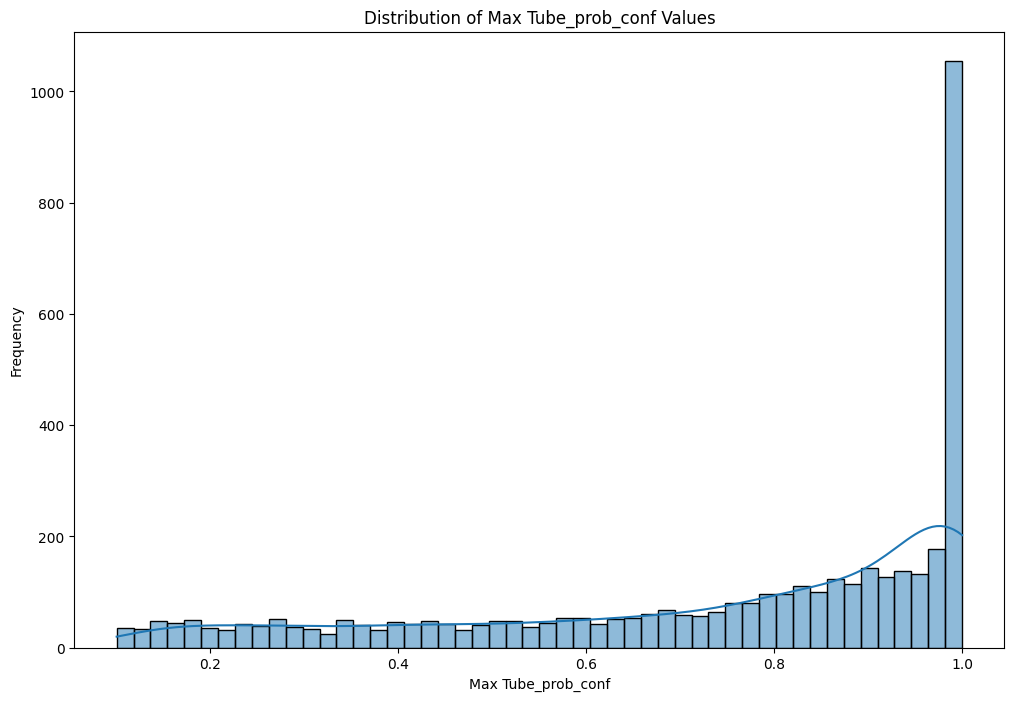

Proportion of videos with max Tube_prob_conf < 0.25: 7.95%
Proportion of videos with max Tube_prob_conf < 0.5: 21.11%
Proportion of videos with max Tube_prob_conf < 0.75: 38.75%


In [265]:
# Get the max Tube_prob_conf for each source_filename.
max_tube_prob_conf = aggregated_df.groupby("source_filename")["Tube_prob_conf"].max().reset_index()

# Plot the distribution of max Tube_prob_conf values as a histogram
plt.figure(figsize=(12, 8))
sns.histplot(max_tube_prob_conf["Tube_prob_conf"], bins=50, kde=True)
plt.title("Distribution of Max Tube_prob_conf Values")
plt.xlabel("Max Tube_prob_conf")
plt.ylabel("Frequency")
plt.show()

# Print the proportion of videos with max Tube_prob_conf < 0.25, < 0.5, and < 0.75
total_videos = len(max_tube_prob_conf)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.25: {(max_tube_prob_conf['Tube_prob_conf'] < 0.25).sum() / total_videos:.2%}"
)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.5: {(max_tube_prob_conf['Tube_prob_conf'] < 0.5).sum() / total_videos:.2%}"
)
print(
    f"Proportion of videos with max Tube_prob_conf < 0.75: {(max_tube_prob_conf['Tube_prob_conf'] < 0.75).sum() / total_videos:.2%}"
)

## Enrich data

In [266]:
# Clean data
df = pd.read_csv(aggregated_csv_file)

# Set tp_feeding to True if tube_prob_conf is greater than 0.5, otherwise set to False
df["tp_feeding"] = df["Tube_prob_conf"] > 0.5
print(f"Set 'tp_feeding' to True in {df['tp_feeding'].sum()} rows, False in {len(df) - df['tp_feeding'].sum()} rows")

Set 'tp_feeding' to True in 72231 rows, False in 56518 rows


In [267]:
# Add device_name which is missing from reprocessed data
if "device_name" not in df.columns:
    import sys
    sys.path.append('../rpi')
    from my_fleet_config import INVENTORY
    from expidite_rpi.core.device_config_objects import DeviceCfg

    # Dump the device_id to device_name mapping from INVENTORY
    devices: list[DeviceCfg] = INVENTORY
    device_id_to_name_map = {device.device_id: device.name for device in devices}

    df["device_name"] = df["device_id"].map(device_id_to_name_map)

# Extract the RPI number from the end of the device name (the characters after the last -)
df["rpi_number"] = df["device_name"].str.extract(r"-(\d+)$")

# Set the RPI type to 4 if the rpi_number is 10 or less
df["rpi_type"] = df["rpi_number"].apply(lambda x: "RPI4" if int(x) <= 10 else "RPI5")

In [268]:
# How many rows don't have a high confidence feeding tube detection (L_tube_conf, R_tube_conf)
df["tube_low_confidence"] = (df["L_tube_conf"] < 0.5) | (df["R_tube_conf"] < 0.5)
print(f"Rows with low confidence feeding tube detection: {df['tube_low_confidence'].sum()}")

Rows with low confidence feeding tube detection: 0


In [269]:
# Calculate the number of tubes detected (0, 1, or 2) based on the confidence values of L_tube_conf and R_tube_conf
df["num_tubes_detected"] = ((df["L_tube_conf"] >= 0.5).astype(int) + (df["R_tube_conf"] >= 0.5).astype(int))

# Default the midpoint to MAX_X / 2
df["tube_midpoint_x"] = MAX_X / 2

# Calculate the midpoint between the L_tube and R_tube positions if 2 tubes were detected
df.loc[df["num_tubes_detected"] == 2, "tube_midpoint_x"] = (df["L_tube_x"] + df["R_tube_x"]) / 2

# Assign all detections to L or R based on their tube_prob_x position relative to the tube_midpoint_x.
# If tube_prob_x is less than tube_midpoint_x, assign to L, otherwise assign to R.
df["feeding_from_tube"] = df.apply(lambda row: "L" if row["Tube_prob_x"] < row["tube_midpoint_x"] else "R", axis=1)

# Calculate the Y position of the appropriate L or R tube
df["feeding_from_tube_y"] = df.apply(lambda row: row["L_tube_y"] if row["feeding_from_tube"] == "L" else row["R_tube_y"], axis=1)
df["feeding_from_tube_x"] = df.apply(lambda row: row["L_tube_x"] if row["feeding_from_tube"] == "L" else row["R_tube_x"], axis=1)

# Calculate the Y distance between the tube_prob detection and the appropriate L or R tube
df["tube_prob_to_tube_y_distance"] = (df["Tube_prob_y"] - df["feeding_from_tube_y"])
df["tube_prob_to_tube_x_distance"] = (df["Tube_prob_x"] - df["feeding_from_tube_x"])

# Calculate the Y distance between the End_prob detection and the appropriate L or R tube
# But set it to NaN if End_prob_conf is less than 0.5, since we don't trust the End_prob detection in that case
df["end_prob_to_tube_y_distance"] = (df["End_prob_y"] - df["feeding_from_tube_y"])
df["end_prob_to_tube_x_distance"] = (df["End_prob_x"] - df["feeding_from_tube_x"])

## Data checks

### Investigate devices where <2 tubes are detected

In [270]:
# Tubes count can be 0, 1 or 2. Tabulate num_tubes_detected by device_id.
df.groupby("device_id")["num_tubes_detected"].value_counts()


device_id     num_tubes_detected
d83add1a11c5  2                     27548
d83add1a11d5  2                     11390
d83add1a1201  2                     10594
d83add1a1270  2                     22063
              1                      1108
              0                       364
d83add1a1288  2                     15479
              1                        12
              0                         6
d83add1a12af  2                      7215
              0                       114
              1                        13
d83add1a12be  2                     32227
              1                       415
              0                       201
Name: count, dtype: int64

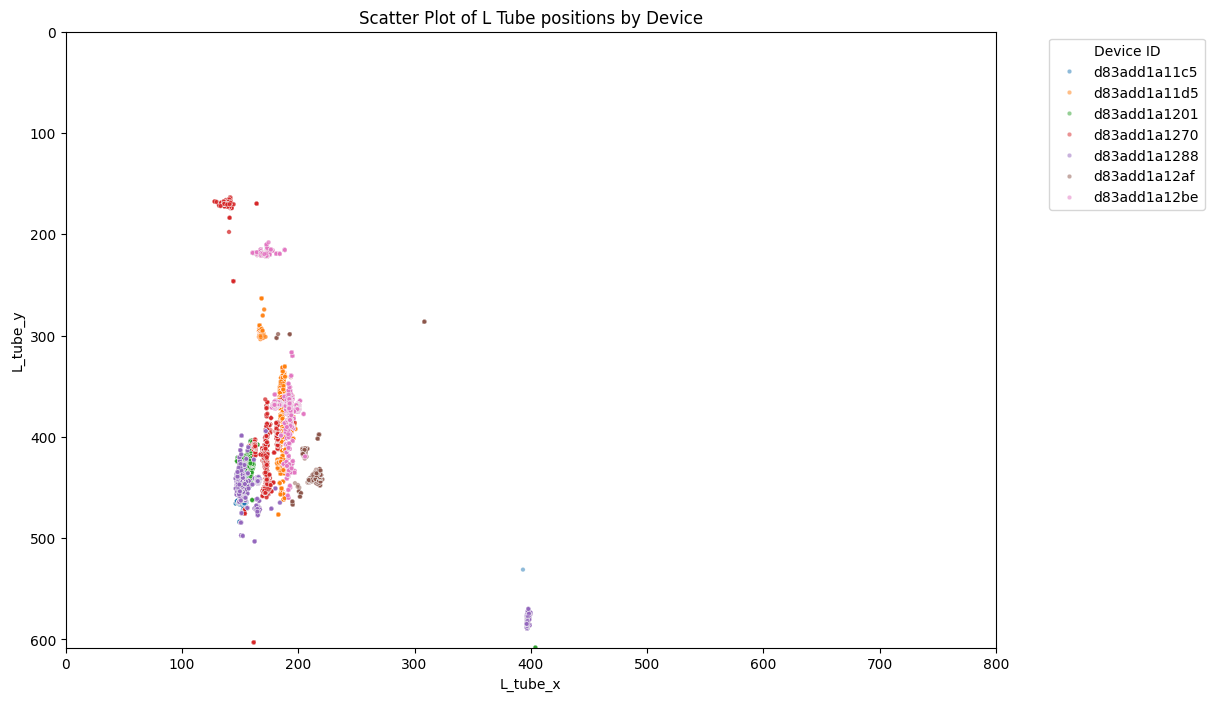

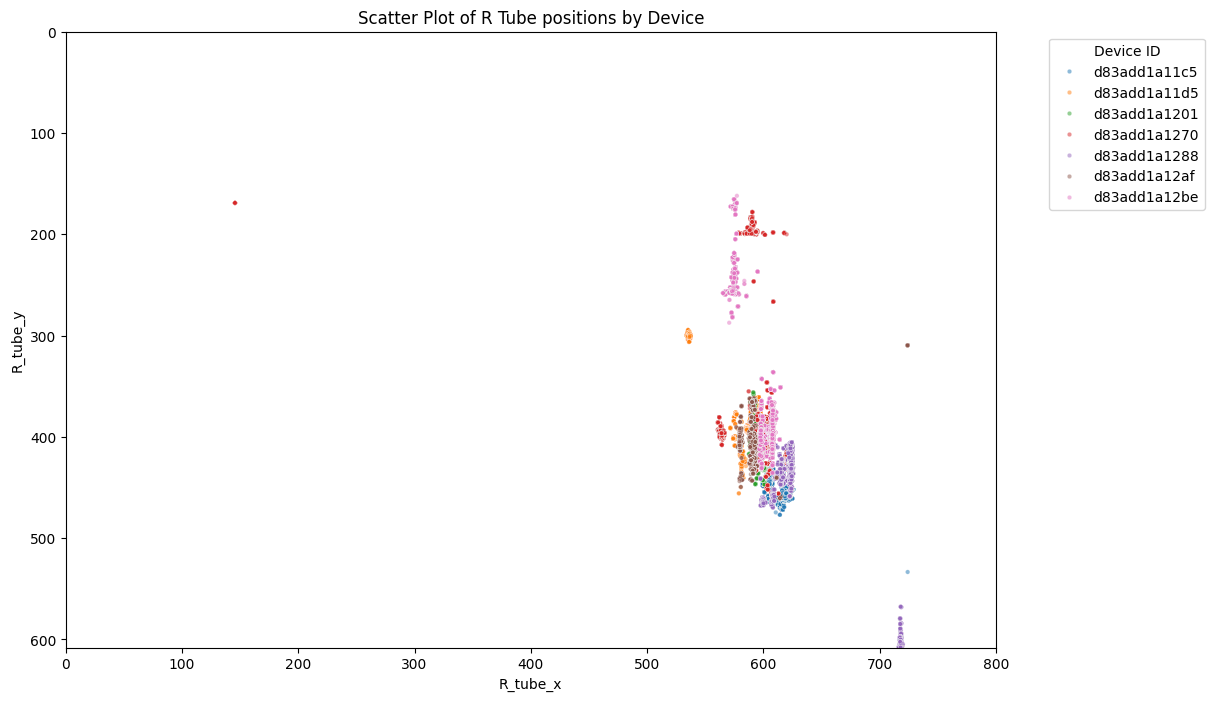

In [273]:
image_plot(df, "L_tube_x", "L_tube_y", title="Scatter Plot of L Tube positions by Device")
image_plot(df, "R_tube_x", "R_tube_y", title="Scatter Plot of R Tube positions by Device")

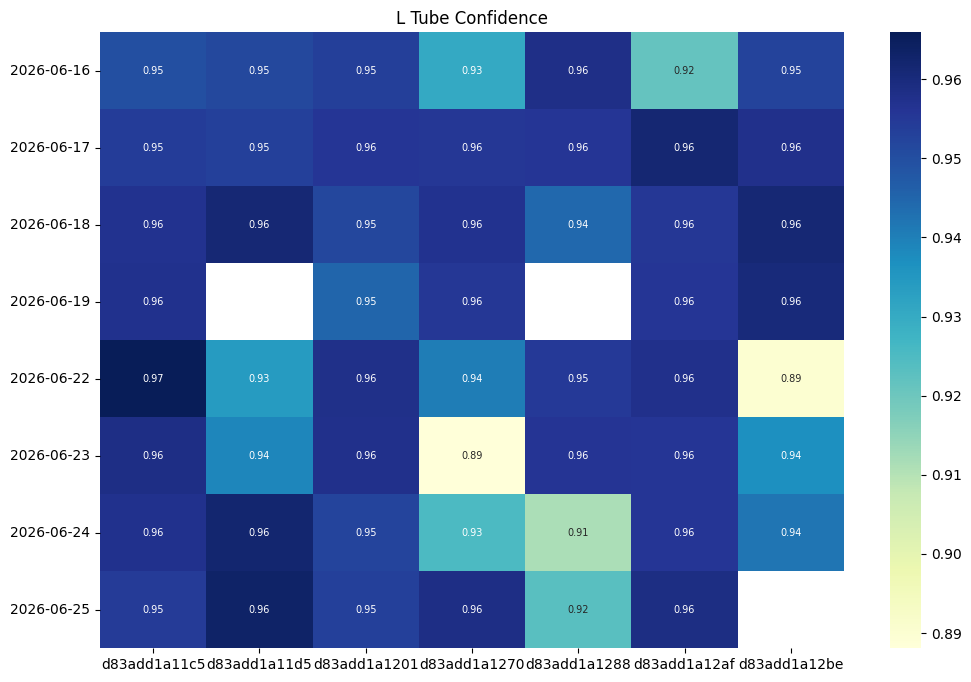

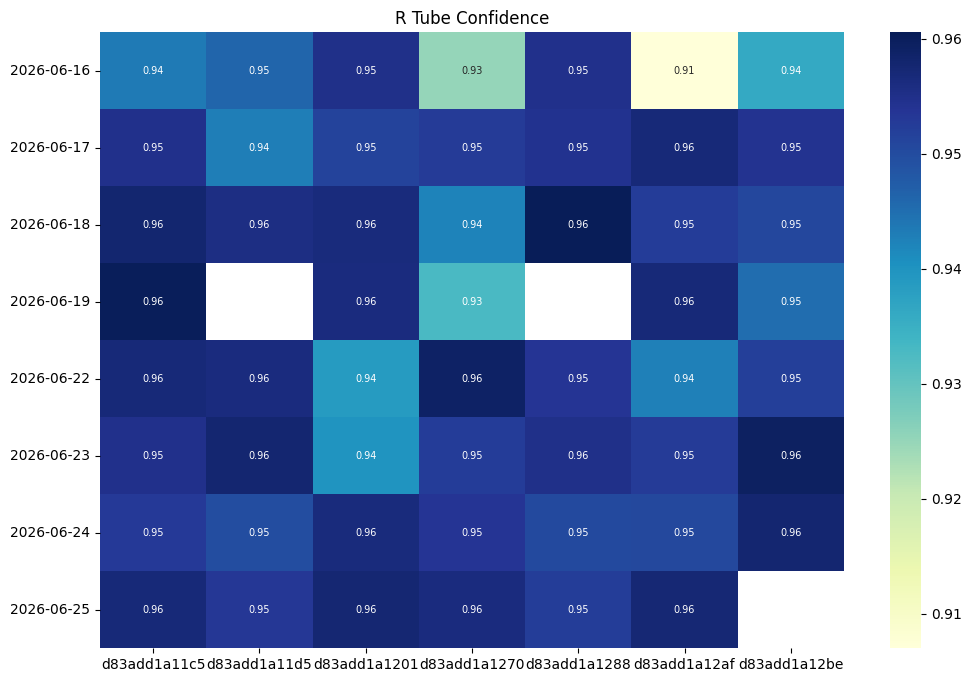

In [271]:
display_heatmap(df, "L_tube_conf", fmt=".2f", title="L Tube Confidence")
display_heatmap(df, "R_tube_conf", fmt=".2f", title="R Tube Confidence")

### Identify tubes that are not well positioned

If the tube X or y is within 10% of the edge of the image, that's bad

In [282]:
BAD_MIN_X = MAX_X / 10
BAD_MAX_X = MAX_X - BAD_MIN_X
BAD_MIN_Y = MAX_Y / 10
BAD_MAX_Y = MAX_Y - BAD_MIN_Y
df["bad_tube_location"] = (
    (df["L_tube_x"] < BAD_MIN_X) |
    (df["L_tube_x"] > BAD_MAX_X) |
    (df["L_tube_y"] < BAD_MIN_Y) |
    (df["L_tube_y"] > BAD_MAX_Y) |
    (df["R_tube_x"] < BAD_MIN_X) |
    (df["R_tube_x"] > BAD_MAX_X) |
    (df["R_tube_y"] < BAD_MIN_Y) |
    (df["R_tube_y"] > BAD_MAX_Y)
)

# Tabulate all examples of bad tube locations by device_id
bad_tube_locations_df = df[df["bad_tube_location"] == True]
print(f"Total rows with bad tube locations: {len(bad_tube_locations_df)}")
bad_by_device = bad_tube_locations_df.groupby(["device_id", "date"])["bad_tube_location"].count()
print("Bad tube locations by device_id:")
print(bad_by_device)

Total rows with bad tube locations: 5129
Bad tube locations by device_id:
device_id     date      
d83add1a11c5  2026-06-16       1
d83add1a1201  2026-06-16       6
d83add1a1270  2026-06-16      25
d83add1a1288  2026-06-16    4009
              2026-06-17    1075
d83add1a12af  2026-06-16      13
Name: bad_tube_location, dtype: int64


## Reliability of tube_prob_ data

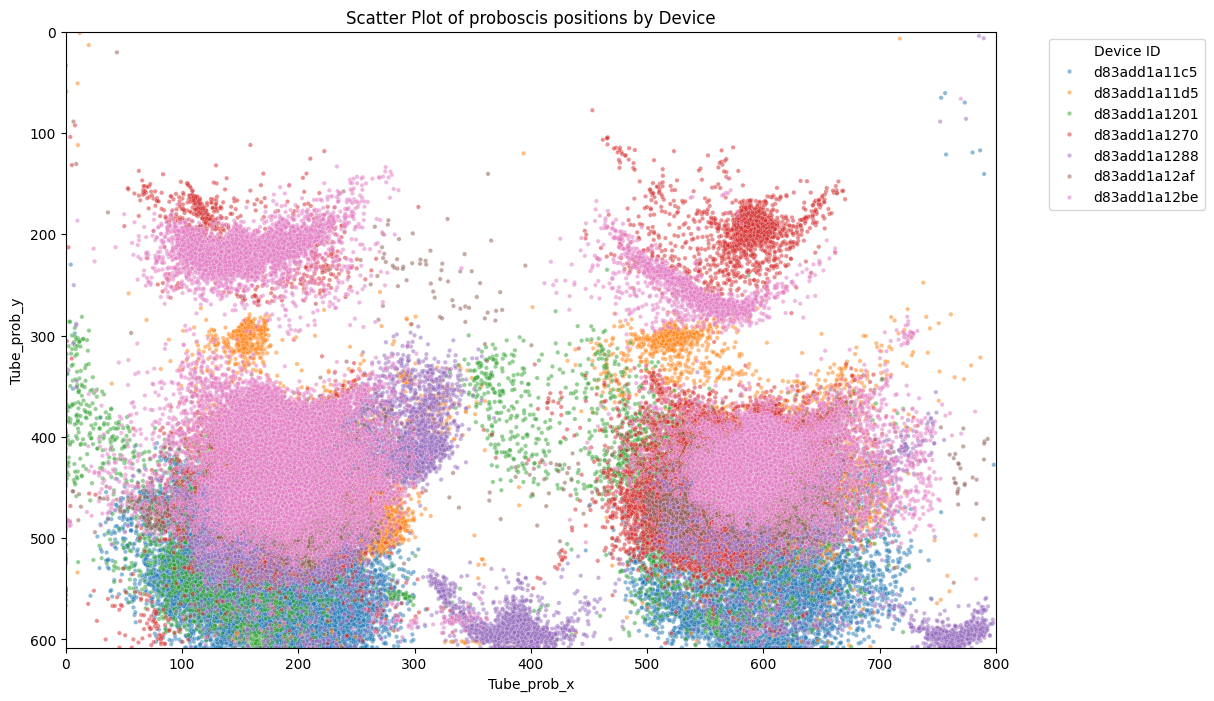

In [272]:
# Plot the XY of the Tube_prob as a scatter plot, colored by device_name
image_plot(df, "Tube_prob_x", "Tube_prob_y", title="Scatter Plot of proboscis positions by Device")

### Reliability of tube_prob_x|y reliative to tube

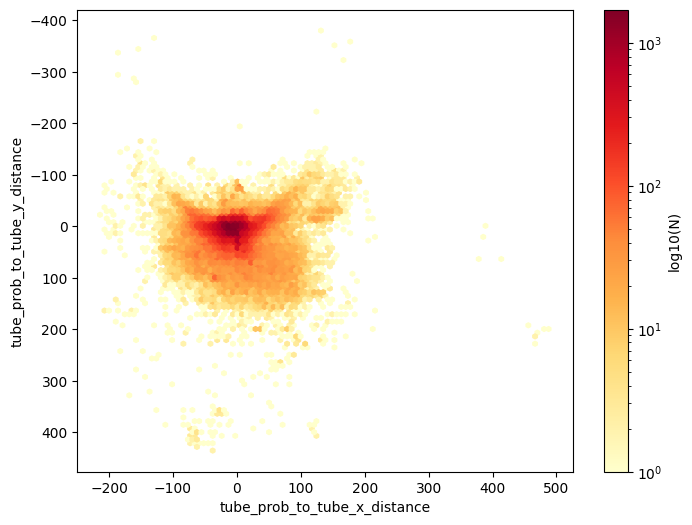

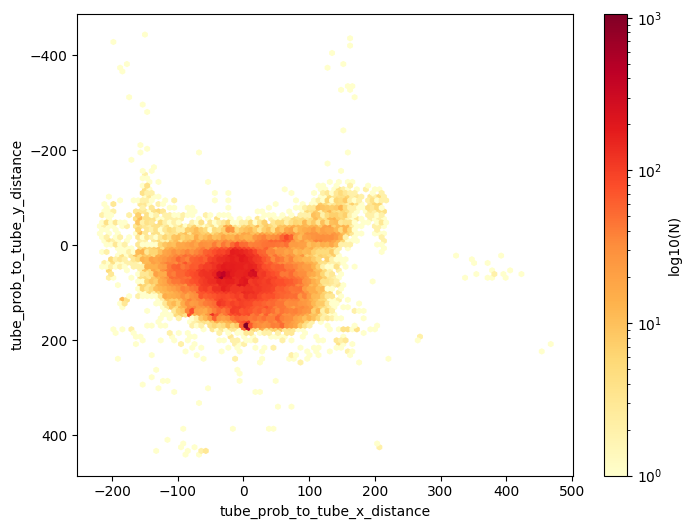

In [274]:
# Create a heatmap of the density of points in the "tube_prob_to_tube_y_distance" and "tube_prob_to_tube_x_distance" columns
# We only want instances where tp_feeding is True, since we only care about the proboscis being detected in the tube.
df_feeding = df[df["tp_feeding"] == True]

# Create cubinned heatmap of the density of points in the "tube_prob_to_tube_y_distance" and "tube_prob_to_tube_x_distance" columns
plt.figure(figsize=(8, 6))
plt.hexbin(df_feeding["tube_prob_to_tube_x_distance"],
           df_feeding["tube_prob_to_tube_y_distance"],
           gridsize=100,
           # Use a yellow to red colormap, with blue being low density and red being high density
           cmap='YlOrRd',
           bins='log')
plt.colorbar(label='log10(N)')
plt.ylim(plt.ylim()[::-1])
plt.xlabel("tube_prob_to_tube_x_distance")
plt.ylabel("tube_prob_to_tube_y_distance")
plt.show()

df_not_feeding = df[df["tp_feeding"] == False]

# Create cubinned heatmap of the density of points in the "tube_prob_to_tube_y_distance" and "tube_prob_to_tube_x_distance" columns
plt.figure(figsize=(8, 6))
plt.hexbin(df_not_feeding["tube_prob_to_tube_x_distance"],
           df_not_feeding["tube_prob_to_tube_y_distance"],
           gridsize=100,
           # Use a yellow to red colormap, with blue being low density and red being high density
           cmap='YlOrRd',
           bins='log')
plt.colorbar(label='log10(N)')
plt.ylim(plt.ylim()[::-1])
plt.xlabel("tube_prob_to_tube_x_distance")
plt.ylabel("tube_prob_to_tube_y_distance")
plt.show()

# Actual feeding data

We're going to define a feeding detection as: 
- tube_prob_conf > 0.5  AND
- tube_conf_x within +/- 150 of feeding_tube_x
- tube_conf_y within +/- 100 of feeding_tube_y
- excluding any rows with bad_tube_location

In [298]:
# Understand what we're excluding
pre_filtered_size = len(df)
pre_filtered_high_conf_size = len(df[df["Tube_prob_conf"] >= 0.5])

df["outside_roi"] = ~(
    (df["tube_prob_to_tube_y_distance"].abs() < 150) &
    (df["tube_prob_to_tube_x_distance"].abs() < 100)
)
df["very_low_conf"] = df["Tube_prob_conf"] < 0.2

# Tabulate rows excluded due to bad tube locations
bad_tube_location_df = df[df["bad_tube_location"] == True]
bad_by_device = bad_tube_locations_df.groupby(["device_id", "date"])["bad_tube_location"].count()

# Tabulate the number of rows that are excluded due to being outside the tube area or having very low confidence
table_df = df.groupby(["outside_roi", "very_low_conf", "bad_tube_location"]).size().reset_index(name="count")

filtered_df = df[~df["very_low_conf"] & ~df["outside_roi"] & ~df["bad_tube_location"]]

print(f"Filtered out {len(bad_tube_location_df)/pre_filtered_size:.1%} due to bad tube locations")
print(f"Filtered out {(df['very_low_conf'].sum()/pre_filtered_size):.1%} due to very low confidence (<0.2)")
print(f"Filtered out {(df['outside_roi'].sum()/pre_filtered_size):.1%} due to ROI (tube_prob_x|y >100 pixels from the tube)")
print(f" - filtered out {(pre_filtered_high_conf_size - len(filtered_df[filtered_df['Tube_prob_conf'] >= 0.5]))/pre_filtered_high_conf_size:.1%} of high confidence rows due to ROI")

filtered_df["feeding"] = filtered_df["Tube_prob_conf"] > 0.5
print(f"Feeding detected in {filtered_df['feeding'].sum()} rows (tube_prob_conf > 0.5) \n")

print("Breakdown of rows excluded:")
print(table_df)


Filtered out 4.0% due to bad tube locations
Filtered out 18.6% due to very low confidence (<0.2)
Filtered out 9.6% due to ROI (tube_prob_x|y >100 pixels from the tube)
 - filtered out 9.5% of high confidence rows due to ROI
Feeding detected in 65381 rows (tube_prob_conf > 0.5) 

Breakdown of rows excluded:
   outside_roi  very_low_conf  bad_tube_location  count
0        False          False              False  91255
1        False          False               True   4722
2        False           True              False  19969
3        False           True               True    390
4         True          False              False   8795
5         True          False               True     11
6         True           True              False   3601
7         True           True               True      6


In [295]:
# Create a new df that defines all the seconds in the data, and whether or not there was a feeding detection in that second.
filtered_df["frame_start_time"] = pd.to_datetime(filtered_df["frame_start_time"], format='ISO8601')
filtered_df["timestamp_s"] = filtered_df["frame_start_time"].dt.floor("s")
seconds_df = filtered_df.groupby(["timestamp_s", "device_id"]).agg(
    feeding_prob_max=("Tube_prob_conf", "max"),
    feeding_prob_sum=("Tube_prob_conf", "sum"),
    feeding_x_delta_mean=("tube_prob_to_tube_x_distance", "mean"),
    feeding_y_delta_mean=("tube_prob_to_tube_y_distance", "mean"),
    frame_start_time=("timestamp_s", "first"),
).reset_index()

# Rather than using a simple "any detection > 0.5" we look at the sum of the confidence values
# for all detections in that second. If the sum is greater than 1.0, we consider that a feeding detection.
seconds_df["feeding_detected_max"] = seconds_df["feeding_prob_max"] > 0.5
seconds_df["feeding_detected_sum"] = seconds_df["feeding_prob_sum"] > 1.5
print(f"Total seconds in data: {len(seconds_df)}")
print(f"Feeding detections [conf_max]: {seconds_df['feeding_detected_max'].sum()}")
print(f"Feeding detections [conf_sum]: {seconds_df['feeding_detected_sum'].sum()}")

# Use feeding_detected_sum to define feeding clusters, since it is more robust to noise and false positives.
seconds_df["feeding_detected"] = seconds_df["feeding_detected_sum"]

# Tabulate feeding_sum by value
seconds_df["feeding_detected_sum"].value_counts().sort_index()

Total seconds in data: 34232
Feeding detections [conf_max]: 22664
Feeding detections [conf_sum]: 13585


feeding_detected_sum
False    20647
True     13585
Name: count, dtype: int64

Feeding detected in seconds: 14440
Feeding detected in consecutive seconds: 10995
Total feeding clusters: 3445
Feeding clusters with duration > 1 second: 2000


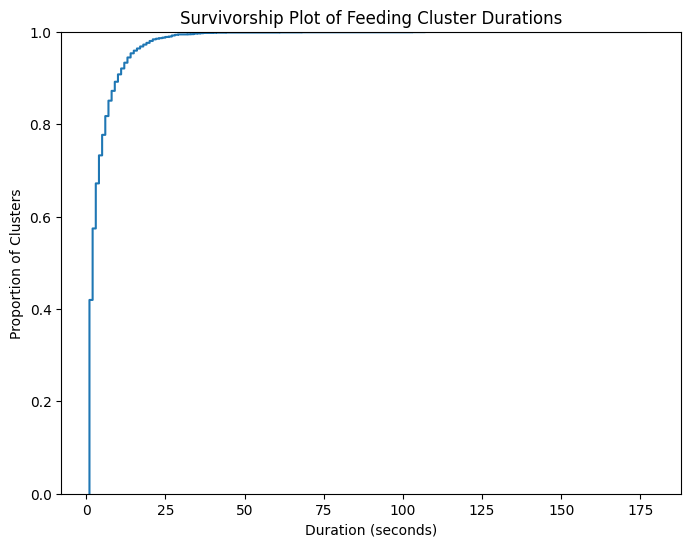

In [277]:
# We want to understand how random or consistent feeding is, so we want to know if the feeding detections are clustered
# together in time, or if they are randomly distributed.
# Calculate the probability that the next second has a feeding detection given that the current second has a feeding detection.
# We can just use shift because we don't necessarily have a row for every second, only when we have events,
# so we need to check the actual timestamp_s values to see if they are consecutive seconds.
print(f"Feeding detected in seconds: {seconds_df['feeding_detected'].sum()}")
feeding_seconds_df = seconds_df[seconds_df["feeding_detected"] == True].copy()
feeding_seconds_df = feeding_seconds_df.sort_values(by=["device_id", "timestamp_s"])

# Get the next second's timestamp_s for each row, and check if it is equal to the current row's timestamp_s + 1 second.
feeding_seconds_df["next_feeding_second"] = feeding_seconds_df["timestamp_s"].shift(-1)
feeding_seconds_df["timestamp_s_plus_1"] = feeding_seconds_df["timestamp_s"] + timedelta(seconds=1)
feeding_seconds_df["consecutive"] = (
    (feeding_seconds_df["next_feeding_second"] == feeding_seconds_df["timestamp_s_plus_1"]) &
    (feeding_seconds_df["device_id"] == feeding_seconds_df["device_id"].shift(-1))
)
print(f"Feeding detected in consecutive seconds: {feeding_seconds_df['consecutive'].sum()}")

feeding_seconds_df["start_of_cluster"] = ~feeding_seconds_df["consecutive"].shift(1, fill_value=False)
feeding_seconds_df["end_of_cluster"] = ~feeding_seconds_df["consecutive"]
feeding_seconds_df["cluster_id"] = feeding_seconds_df["start_of_cluster"].cumsum()

feeding_clusters_df = feeding_seconds_df.groupby("cluster_id").agg(
    frame_start_time=("timestamp_s", "min"),
    end_time=("timestamp_s", "max"),
    duration=("timestamp_s", lambda x: (x.max() - x.min()).total_seconds() + 1),
    device_id=("device_id", "first"),
).reset_index()

print(f"Total feeding clusters: {len(feeding_clusters_df)}")
print(f"Feeding clusters with duration > 1 second: {len(feeding_clusters_df[feeding_clusters_df['duration'] > 1])}")

# Create a survivorship plot of the feeding cluster durations
plt.figure(figsize=(8, 6))
sns.ecdfplot(feeding_clusters_df["duration"])
plt.title("Survivorship Plot of Feeding Cluster Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Proportion of Clusters")
plt.show()


Feeding detected in seconds: 14440
Feeding detected in consecutive seconds: 11922
Total feeding clusters: 2518
Feeding clusters with duration > 1 second: 1622


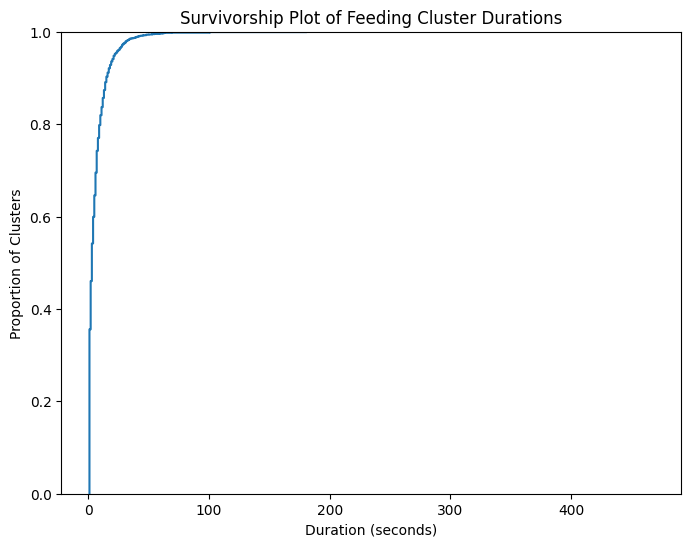

In [278]:
# Repeat, but allow up to a 1 second gap in the feeding detection
gap_size = 5

print(f"Feeding detected in seconds: {seconds_df['feeding_detected'].sum()}")
feeding_seconds_df = seconds_df[seconds_df["feeding_detected"] == True].copy()
feeding_seconds_df = feeding_seconds_df.sort_values(by=["device_id", "timestamp_s"])

# Get the next second's timestamp_s for each row, and check if it is equal to the current row's timestamp_s + 1 second.
feeding_seconds_df["next_feeding_second"] = feeding_seconds_df["timestamp_s"].shift(-1)
feeding_seconds_df["timestamp_s_plus_gap"] = feeding_seconds_df["timestamp_s"] + timedelta(seconds=gap_size+1)
feeding_seconds_df["consecutive"] = (
    (feeding_seconds_df["next_feeding_second"] <= feeding_seconds_df["timestamp_s_plus_gap"]) &
    (feeding_seconds_df["device_id"] == feeding_seconds_df["device_id"].shift(-1))
)
print(f"Feeding detected in consecutive seconds: {feeding_seconds_df['consecutive'].sum()}")

feeding_seconds_df["start_of_cluster"] = ~feeding_seconds_df["consecutive"].shift(1, fill_value=False)
feeding_seconds_df["end_of_cluster"] = ~feeding_seconds_df["consecutive"]
feeding_seconds_df["cluster_id"] = feeding_seconds_df["start_of_cluster"].cumsum()

feeding_clusters_df = feeding_seconds_df.groupby("cluster_id").agg(
    start_time=("timestamp_s", "min"),
    end_time=("timestamp_s", "max"),
    duration=("timestamp_s", lambda x: (x.max() - x.min()).total_seconds() + 1),
    device_id=("device_id", "first"),
).reset_index()

print(f"Total feeding clusters: {len(feeding_clusters_df)}")
print(f"Feeding clusters with duration > 1 second: {len(feeding_clusters_df[feeding_clusters_df['duration'] > 1])}")

# Create a survivorship plot of the feeding cluster durations
plt.figure(figsize=(8, 6))
sns.ecdfplot(feeding_clusters_df["duration"])
plt.title("Survivorship Plot of Feeding Cluster Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Proportion of Clusters")
plt.show()


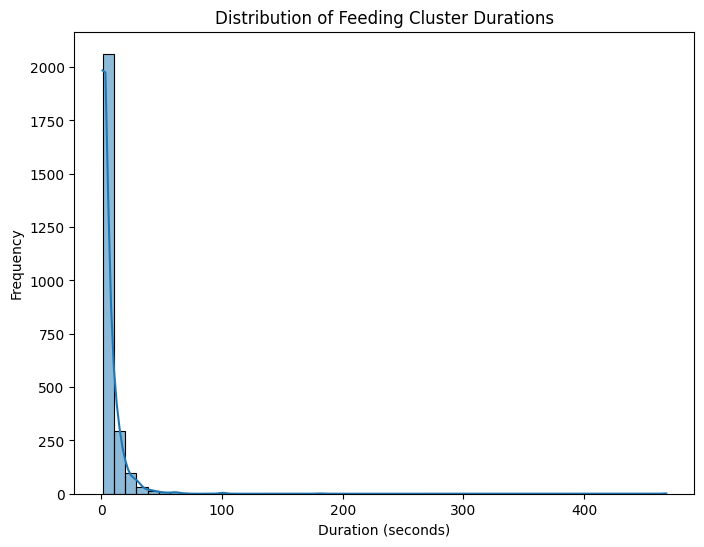

In [279]:
# Plot a histogram of the feeding cluster durations
plt.figure(figsize=(8, 6))
sns.histplot(feeding_clusters_df["duration"], bins=50, kde=True)
plt.title("Distribution of Feeding Cluster Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

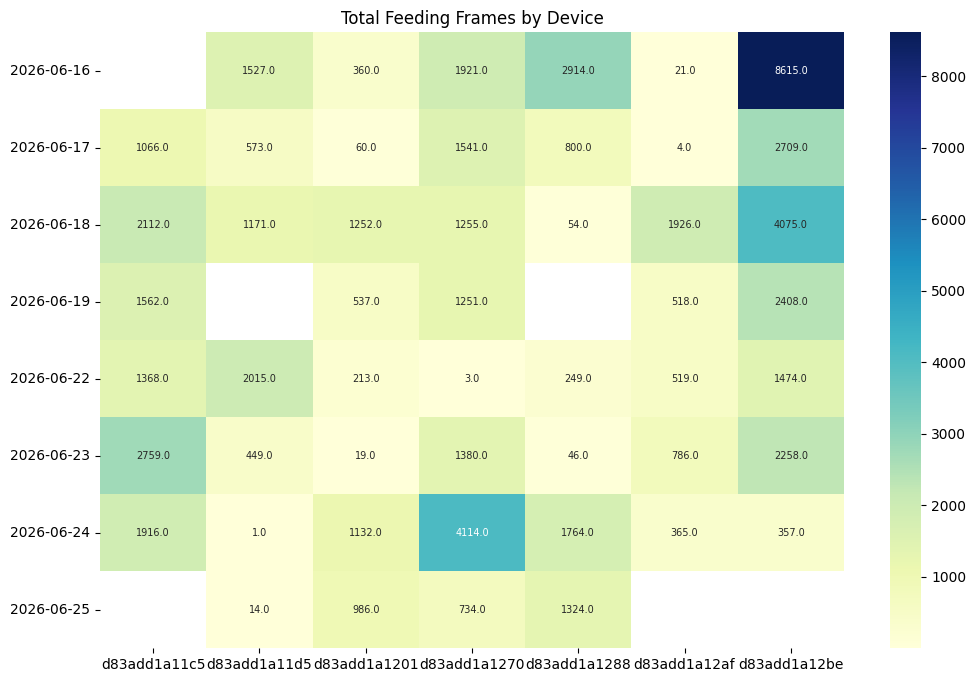

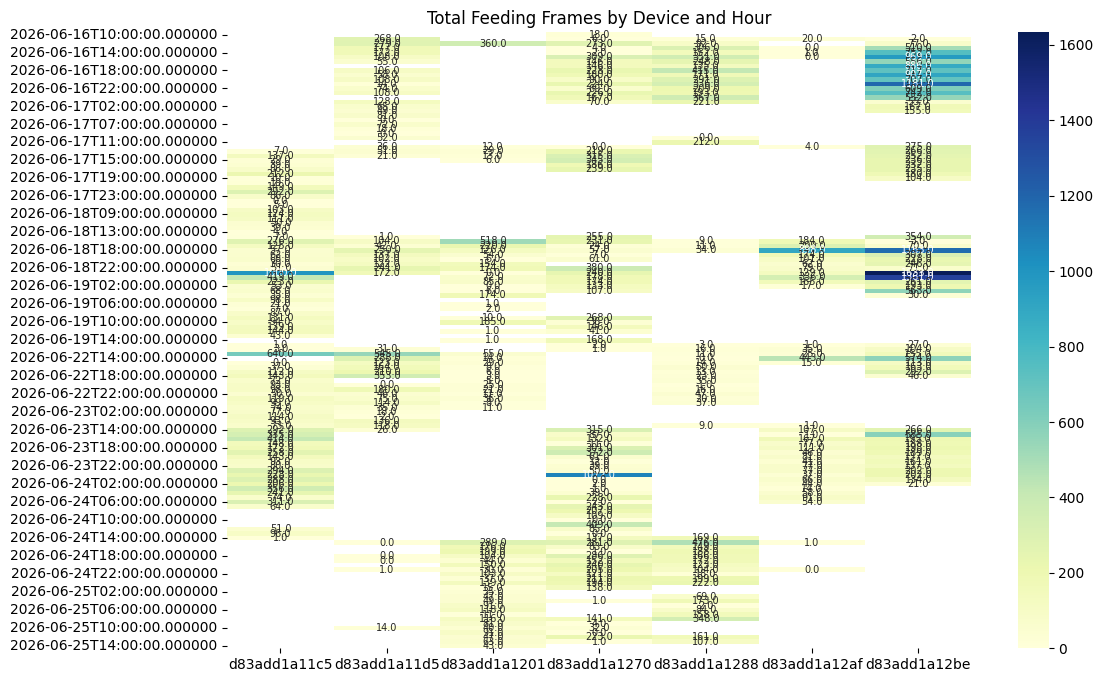

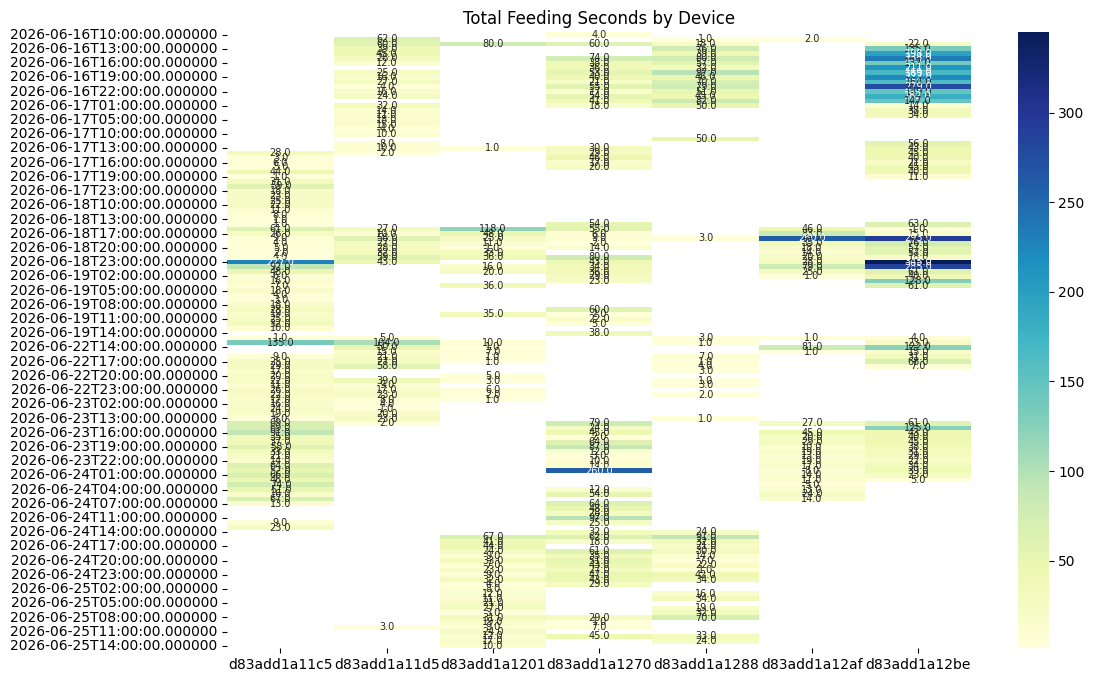

In [280]:
# Display a heatmap of the total feeding frames by device and date
display_heatmap(filtered_df, "feeding", "sum", "Total Feeding Frames by Device")
display_heatmap_by_hour(filtered_df, "feeding", "sum", "Total Feeding Frames by Device and Hour")
display_heatmap_by_hour(feeding_seconds_df, "feeding_detected", "sum", "Total Feeding Seconds by Device")